In [ ]:
!pip install hmmlearn
!pip install fredapi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.5 MB/s eta 0:00:00


═════════════════════════════════════════════════════════════════
  STEP 1 — DATA
═════════════════════════════════════════════════════════════════
  ↻ Cache outdated (2026-04-10), refreshing...
  ✓ Fetched and cached (5903 days)
  Observations : 5903 daily periods
  Date range   : 2002-09-04 → 2026-04-10

═════════════════════════════════════════════════════════════════
  STEP 2 — FIT HMM
═════════════════════════════════════════════════════════════════
  Running 50 restarts in parallel (n_jobs=-1)...
  Successful   : 50 / 50 runs
  Best log-lik : 61198.4327
  Score std    : 113.7205

═════════════════════════════════════════════════════════════════
  STEP 3 — REGIME PARAMETERS
═════════════════════════════════════════════════════════════════
═══════════════════════════════════════════════════════════════════════════
  REGIME PARAMETER ESTIMATES
  (means annualised × 252, volatility annualised × √252)
═══════════════════════════════════════════════════════════════════════════
  Regime

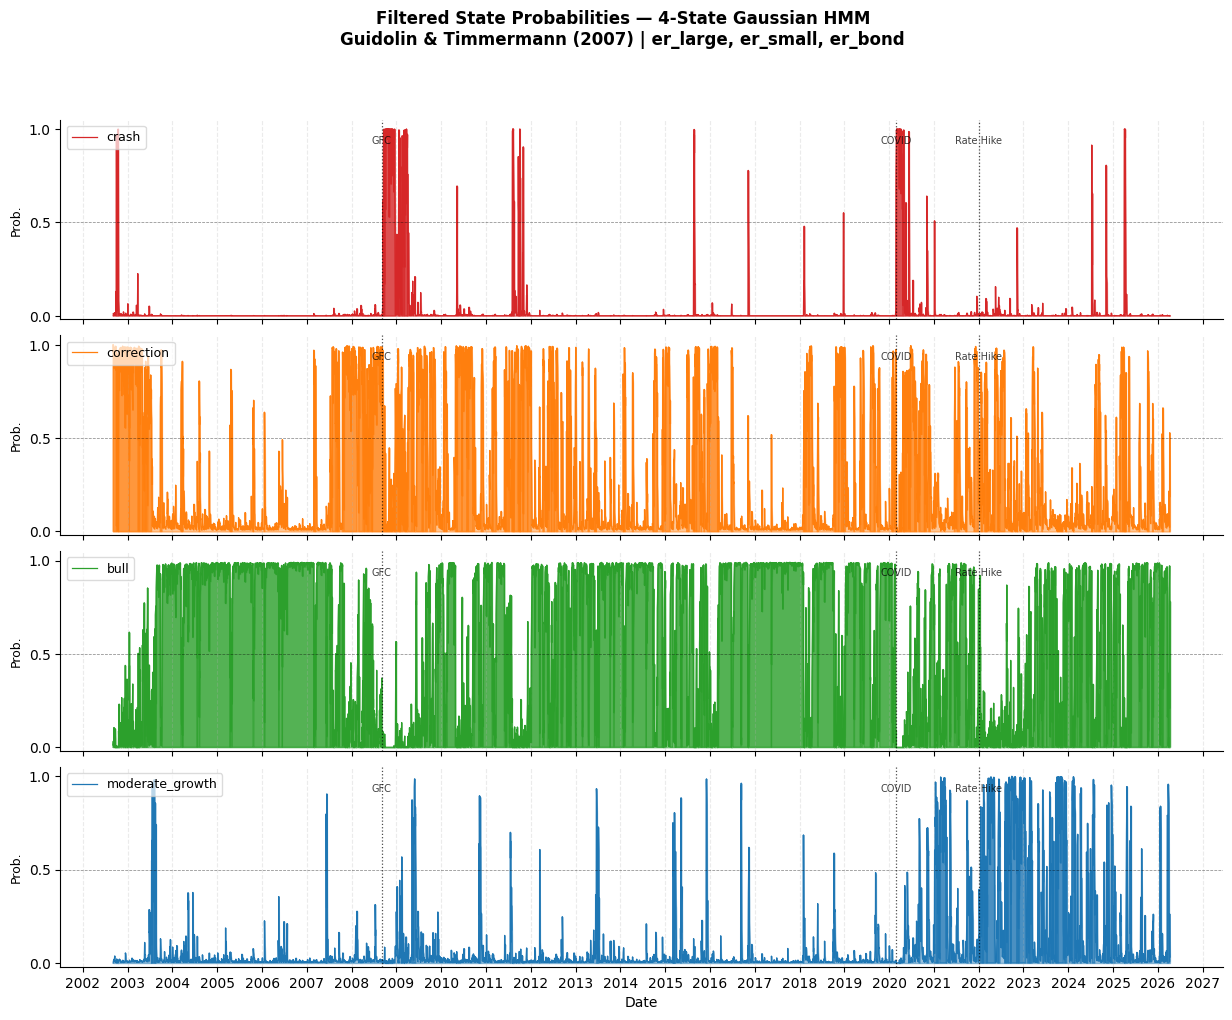


══════════════════════════════════════════════════
  TODAY'S REGIME SIGNAL
══════════════════════════════════════════════════
shape: (1, 7)
┌──────────────┬────────┬────────────┬─────────────────┬───────────┬────────────────────┬──────────┐
│ date         ┆ regime ┆ prob_crash ┆ prob_correction ┆ prob_bull ┆ prob_moderate_grow ┆ max_prob │
│ ---          ┆ ---    ┆ ---        ┆ ---             ┆ ---       ┆ th                 ┆ ---      │
│ datetime[ns] ┆ str    ┆ f64        ┆ f64             ┆ f64       ┆ ---                ┆ f64      │
│              ┆        ┆            ┆                 ┆           ┆ f64                ┆          │
╞══════════════╪════════╪════════════╪═════════════════╪═══════════╪════════════════════╪══════════╡
│ 2026-04-10   ┆ bull   ┆ 0.000129   ┆ 0.186752        ┆ 0.781289  ┆ 0.031829           ┆ 0.781289 │
│ 00:00:00     ┆        ┆            ┆                 ┆           ┆                    ┆          │
└──────────────┴────────┴────────────┴─────────────

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# REGIME DETECTION — PRODUCTION PIPELINE
# Guidolin & Timmermann (2007) | Daily Data
#
# Optimisations:
#   1. Parallelised EM restarts     — joblib across all CPU cores
#   2. Numba forward loop           — JIT compiled if available
#   3. Online filter update         — O(k²) single day update
#   4. Warm starting                — previous model as initialisation
#   5. Adaptive restarts            — fewer restarts as model stabilises
#   6. Data cache                   — no repeated API calls
# ══════════════════════════════════════════════════════════════════════════════

import os
import logging
import warnings
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from scipy import linalg
from joblib import Parallel, delayed
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred
import yfinance as yf

try:
    from numba import njit
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False

warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════

FRED_API_KEY  = "fab639e6cb13dc505bb2bed3f9030859"
START_DATE    = "2002-09-01"
END_DATE      = datetime.today().strftime("%Y-%m-%d")
CACHE_PATH    = "regime_data_cache.parquet"
RESULTS_PATH  = "regime_results.parquet"

N_STATES      = 4
MAX_ITER      = 300
TOL           = 1e-1
N_JOBS        = -1        # -1 = all CPU cores

FEATURES      = ["er_large", "er_small", "er_bond"]
REGIME_ORDER  = ["crash", "correction", "bull", "moderate_growth"]
REGIME_COLORS = {
    "crash":           "#d62728",
    "correction":      "#ff7f0e",
    "bull":            "#2ca02c",
    "moderate_growth": "#1f77b4",
}
EVENTS = [
    ("2008-09-01", "GFC"),
    ("2020-03-01", "COVID"),
    ("2022-01-01", "Rate Hike"),
]
PRICE_TICKERS = {
    "SPY":  "spy",
    "IWM":  "iwm",
    "TLT":  "tlt",
    "^VIX": "vix",
}
FRED_SERIES = {
    "DTB3":         "tbill_ann",
    "GS10":         "yield_10y",
    "GS2":          "yield_2y",
    "BAMLH0A0HYM2": "hy_oas",
}

# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA WITH CACHE
# ══════════════════════════════════════════════════════════════════════════════

def fetch_prices(ticker_map, start, end):
    tickers = list(ticker_map.keys())
    raw     = yf.download(tickers, start=start, end=end,
                          auto_adjust=True, progress=False)
    close   = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
    daily   = close.resample("B").last().ffill()
    daily.index.name = "date"
    df = pl.from_pandas(daily.reset_index())
    rename_map = {
        col: ticker_map.get(col, col.lower().replace("^", ""))
        for col in df.columns if col != "date"
    }
    return df.rename(rename_map)


def fetch_fred(series_map, api_key, start, end):
    fred   = Fred(api_key=api_key)
    frames = {}
    for series_id, col_name in series_map.items():
        s = fred.get_series(series_id, observation_start=start, observation_end=end)
        frames[col_name] = s
    df_pd = pd.DataFrame(frames)
    df_pd.index = pd.to_datetime(df_pd.index)
    daily = df_pd.resample("B").ffill()
    daily.index.name = "date"
    return pl.from_pandas(daily.reset_index())


def load_data(use_cache=True):
    today = datetime.today().strftime("%Y-%m-%d")

    if use_cache and os.path.exists(CACHE_PATH):
        cached     = pl.read_parquet(CACHE_PATH)
        cached_end = str(cached["date"].max())[:10]
        if cached_end >= today:
            print(f"  ✓ Cached data (up to {cached_end})")
            return cached
        print(f"  ↻ Cache outdated ({cached_end}), refreshing...")

    prices  = fetch_prices(PRICE_TICKERS, START_DATE, END_DATE)
    fred_df = fetch_fred(FRED_SERIES, FRED_API_KEY, START_DATE, END_DATE)

    returns = (
        prices.sort("date")
        .with_columns([
            (pl.col("spy").log() - pl.col("spy").shift(1).log()).alias("r_large"),
            (pl.col("iwm").log() - pl.col("iwm").shift(1).log()).alias("r_small"),
            (pl.col("tlt").log() - pl.col("tlt").shift(1).log()).alias("r_bond"),
        ])
    )

    data = (
        returns
        .join(fred_df, on="date", how="left")
        .with_columns([
            (pl.col("tbill_ann") / 100.0 / 252.0).alias("rf_daily"),
            (pl.col("yield_10y") - pl.col("yield_2y")).alias("term_spread"),
        ])
        .with_columns([
            (pl.col("r_large") - pl.col("rf_daily")).alias("er_large"),
            (pl.col("r_small") - pl.col("rf_daily")).alias("er_small"),
            (pl.col("r_bond")  - pl.col("rf_daily")).alias("er_bond"),
        ])
        .drop_nulls(subset=["er_large", "er_small", "er_bond", "rf_daily"])
        .select([
            "date", "er_large", "er_small", "er_bond",
            "r_large", "r_small", "r_bond", "rf_daily",
            "vix", "term_spread", "hy_oas",
            "yield_10y", "yield_2y", "tbill_ann",
        ])
    )

    data.write_parquet(CACHE_PATH)
    print(f"  ✓ Fetched and cached ({data.shape[0]} days)")
    return data


# ══════════════════════════════════════════════════════════════════════════════
# 2. NUMBA FORWARD LOOP
# ══════════════════════════════════════════════════════════════════════════════

if NUMBA_AVAILABLE:
    @njit
    def _forward_loop(fwd, log_em, transmat):
        n_samples, n_states = fwd.shape
        for t in range(1, n_samples):
            pred = fwd[t-1] @ transmat
            for k in range(n_states):
                fwd[t, k] = pred[k] * np.exp(log_em[t, k])
            total = fwd[t].sum()
            if total > 0:
                fwd[t] /= total
        return fwd

    def filtered_probs_full(model, X):
        n_samples = X.shape[0]
        log_em    = model._compute_log_likelihood(X)
        fwd       = np.zeros((n_samples, model.n_components))
        fwd[0]    = model.startprob_ * np.exp(log_em[0])
        fwd[0]   /= fwd[0].sum()
        return _forward_loop(fwd, log_em, model.transmat_)

else:
    def filtered_probs_full(model, X):
        n_samples = X.shape[0]
        log_em    = model._compute_log_likelihood(X)
        fwd       = np.zeros((n_samples, model.n_components))
        fwd[0]    = model.startprob_ * np.exp(log_em[0])
        fwd[0]   /= fwd[0].sum()
        for t in range(1, n_samples):
            pred   = fwd[t-1] @ model.transmat_
            fwd[t] = pred * np.exp(log_em[t])
            s      = fwd[t].sum()
            if s > 0:
                fwd[t] /= s
        return fwd


# ══════════════════════════════════════════════════════════════════════════════
# 3. ONLINE FILTER UPDATE — O(k²) SINGLE DAY
# Teammates call this daily — no need to rerun full forward pass
# ══════════════════════════════════════════════════════════════════════════════

def update_filter_one_day(prev_filtered, new_returns, model):
    """
    Update filtered probability with one new day of returns.
    Called by teammates every day after market close.

    prev_filtered : (k,) array — yesterday's filtered probabilities
    new_returns   : (3,) array — today's [er_large, er_small, er_bond]
    returns       : (k,) array — today's updated filtered probabilities
    """
    predicted = prev_filtered @ model.transmat_
    log_em    = model._compute_log_likelihood(new_returns.reshape(1, -1))
    updated   = predicted * np.exp(log_em[0])
    total     = updated.sum()
    if total > 0:
        updated /= total
    else:
        updated = predicted
    return updated


# ══════════════════════════════════════════════════════════════════════════════
# 4. ADAPTIVE RESTARTS
# ══════════════════════════════════════════════════════════════════════════════

def get_n_restarts(n_train_days, has_prev_model):
    """
    Fewer restarts as dataset grows and warm start becomes more effective.
    Backtest callers use this to avoid overfitting restarts to runtime.
    """
    if not has_prev_model:
        return 50       # first fit — no warm start
    if n_train_days < 500:
        return 20
    elif n_train_days < 1000:
        return 10
    elif n_train_days < 2000:
        return 7
    else:
        return 5


# ══════════════════════════════════════════════════════════════════════════════
# 5. PARALLELISED HMM FITTING WITH WARM START
# ══════════════════════════════════════════════════════════════════════════════

def _fit_single(seed, X, n_states, max_iter, tol, prev_model=None):
    try:
        m = GaussianHMM(
            n_components=n_states,
            covariance_type="full",
            n_iter=max_iter,
            tol=tol,
            random_state=seed,
            verbose=False,
        )
        # Seed 0 always uses warm start from previous model if available
        if prev_model is not None and seed == 0:
            m.startprob_ = prev_model.startprob_.copy()
            m.transmat_  = prev_model.transmat_.copy()
            m.means_     = prev_model.means_.copy()
            m.covars_    = prev_model.covars_.copy()

        m.fit(X)
        return m.score(X), m
    except Exception:
        return None


def fit_hmm(X, n_restarts=25, prev_model=None, n_jobs=N_JOBS):
    """
    Fit HMM with parallelised restarts and optional warm start.
    prev_model: pass previously fitted model to warm start seed 0.
    """
    results = Parallel(n_jobs=n_jobs)(
        delayed(_fit_single)(seed, X, N_STATES, MAX_ITER, TOL, prev_model)
        for seed in range(n_restarts)
    )
    results = [r for r in results if r is not None]
    if not results:
        raise RuntimeError("All HMM fits failed")
    scores = [r[0] for r in results]
    _, best_model = max(results, key=lambda r: r[0])

    print(f"  Successful   : {len(results)} / {n_restarts} runs")
    print(f"  Best log-lik : {max(scores):.4f}")
    print(f"  Score std    : {np.std(scores):.4f}")
    return best_model


# ══════════════════════════════════════════════════════════════════════════════
# 6. REGIME LABELLING
# ══════════════════════════════════════════════════════════════════════════════

def label_states(model):
    lc_means = model.means_[:, 0]
    lc_vols  = np.sqrt(np.array([c[0, 0] for c in model.covars_]) * 252)

    sorted_idx          = sorted(range(N_STATES), key=lambda i: lc_means[i])
    crash_raw           = sorted_idx[0]
    correction_raw      = sorted_idx[1]
    moderate_growth_raw = sorted_idx[2]
    bull_raw            = sorted_idx[3]

    raw_to_name   = {
        crash_raw:           "crash",
        correction_raw:      "correction",
        moderate_growth_raw: "moderate_growth",
        bull_raw:            "bull",
    }
    canonical_idx = [crash_raw, correction_raw, bull_raw, moderate_growth_raw]

    return raw_to_name, canonical_idx, lc_vols


# ══════════════════════════════════════════════════════════════════════════════
# 7. SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════════════════

def print_regime_summary(model, canonical_idx, lc_vols):
    means_raw    = model.means_
    transmat_raw = model.transmat_

    eigvals, eigvecs = linalg.eig(transmat_raw.T)
    ss_vec   = eigvecs[:, np.argmax(eigvals.real)].real
    ss_probs = ss_vec / ss_vec.sum()

    def avg_dur(p): return 1.0 / (1.0 - p) if p < 1.0 else np.inf

    print("═" * 75)
    print("  REGIME PARAMETER ESTIMATES")
    print("  (means annualised × 252, volatility annualised × √252)")
    print("═" * 75)
    print(
        f"  {'Regime':<16} {'Mean LC':>9} {'Mean SC':>9} {'Mean BD':>9} "
        f"{'Vol LC':>9} {'Persist':>8} {'Avg Dur':>9} {'SS Prob':>8}"
    )
    print("  " + "─" * 75)

    for name, raw_idx in zip(REGIME_ORDER, canonical_idx):
        m_ann  = means_raw[raw_idx] * 252
        v_ann  = lc_vols[raw_idx]
        p_self = transmat_raw[raw_idx, raw_idx]
        dur    = avg_dur(p_self)
        ss     = ss_probs[raw_idx]
        print(
            f"  {name:<16} {m_ann[0]:>+9.2%} {m_ann[1]:>+9.2%} {m_ann[2]:>+9.2%} "
            f"{v_ann:>9.2%} {p_self:>8.3f} {dur:>8.1f}d {ss:>8.1%}"
        )

    print("\n  TRANSITION MATRIX  P(row → col)")
    print("  " + "─" * 70)
    print("  " + f"{'':18}" + "".join(f"{n:>14}" for n in REGIME_ORDER))
    for from_name, from_raw in zip(REGIME_ORDER, canonical_idx):
        row = [transmat_raw[from_raw, to_raw] for to_raw in canonical_idx]
        print(f"  {from_name:<18}" + "".join(f"{v:>14.3f}" for v in row))


# ══════════════════════════════════════════════════════════════════════════════
# 8. BUILD RESULTS DATAFRAME
# ══════════════════════════════════════════════════════════════════════════════

def build_results(data, model, canonical_idx, raw_to_name, X):
    state_probs_raw = filtered_probs_full(model, X)
    viterbi_raw     = model.predict(X)

    state_probs   = state_probs_raw[:, canonical_idx]
    viterbi_named = np.array([raw_to_name[s] for s in viterbi_raw])

    results = (
        data
        .with_columns([
            pl.Series("regime",               viterbi_named.tolist()),
            pl.Series("prob_crash",           state_probs[:, 0].tolist()),
            pl.Series("prob_correction",      state_probs[:, 1].tolist()),
            pl.Series("prob_bull",            state_probs[:, 2].tolist()),
            pl.Series("prob_moderate_growth", state_probs[:, 3].tolist()),
            pl.Series("max_prob",             state_probs.max(axis=1).tolist()),
        ])
    )

    print("\n  SAMPLE REGIME FREQUENCIES")
    print("  " + "─" * 35)
    freq = (
        results
        .group_by("regime")
        .agg(pl.len().alias("days"))
        .with_columns((pl.col("days") / results.shape[0]).alias("pct"))
        .sort("days", descending=True)
    )
    for row in freq.iter_rows(named=True):
        print(f"  {row['regime']:<16} {row['days']:>4} days  ({row['pct']:.1%})")

    return results, state_probs


# ══════════════════════════════════════════════════════════════════════════════
# 9. PLOT
# ══════════════════════════════════════════════════════════════════════════════

def plot_regimes(dates, state_probs):
    fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True,
                              gridspec_kw={"hspace": 0.08})
    fig.suptitle(
        "Filtered State Probabilities — 4-State Gaussian HMM\n"
        "Guidolin & Timmermann (2007) | er_large, er_small, er_bond",
        fontsize=12, fontweight="bold", y=0.98
    )

    for ax, regime_name, col_idx in zip(axes, REGIME_ORDER, range(4)):
        probs = state_probs[:, col_idx]
        color = REGIME_COLORS[regime_name]

        ax.fill_between(dates, probs, alpha=0.45, color=color)
        ax.plot(dates, probs, color=color, linewidth=0.9, label=regime_name)
        ax.axhline(0.5, color="black", linestyle="--", linewidth=0.55, alpha=0.45)

        dominant = probs > 0.5
        ax.fill_between(dates, 0, probs, where=dominant,
                        alpha=0.65, color=color, interpolate=True)

        for evt_date, evt_label in EVENTS:
            evt_dt = pd.Timestamp(evt_date)
            if dates.min() <= evt_dt <= dates.max():
                ax.axvline(evt_dt, color="black", linestyle=":",
                           linewidth=0.9, alpha=0.7)
                ax.text(evt_dt, 0.92, evt_label, fontsize=7,
                        ha="center", color="black", alpha=0.75)

        ax.set_ylim(-0.02, 1.05)
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_ylabel("Prob.", fontsize=9)
        ax.legend(loc="upper left", fontsize=9, framealpha=0.7)
        ax.grid(axis="x", alpha=0.25, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1].xaxis.set_major_locator(mdates.YearLocator(1))
    axes[-1].set_xlabel("Date", fontsize=10)
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 10. TODAY'S SIGNAL
# ══════════════════════════════════════════════════════════════════════════════

def get_todays_signal(results):
    """
    Returns today's regime probabilities.
    This is what teammates consume every day.
    """
    today = results.sort("date").tail(1)
    print("\n" + "═" * 50)
    print("  TODAY'S REGIME SIGNAL")
    print("═" * 50)
    print(today.select([
        "date", "regime",
        "prob_crash", "prob_correction",
        "prob_bull", "prob_moderate_growth",
        "max_prob",
    ]))
    return today


# ══════════════════════════════════════════════════════════════════════════════
# 11. MAIN
# ══════════════════════════════════════════════════════════════════════════════

print("═" * 65)
print("  STEP 1 — DATA")
print("═" * 65)
data  = load_data(use_cache=True)
dates = pd.to_datetime(data["date"].to_pandas())
X     = data.select(FEATURES).to_numpy()
print(f"  Observations : {X.shape[0]} daily periods")
print(f"  Date range   : {dates.min().date()} → {dates.max().date()}")

print("\n" + "═" * 65)
print("  STEP 2 — FIT HMM")
print("═" * 65)
n_restarts = get_n_restarts(X.shape[0], has_prev_model=False)
print(f"  Running {n_restarts} restarts in parallel (n_jobs={N_JOBS})...")
model = fit_hmm(X, n_restarts=n_restarts)

print("\n" + "═" * 65)
print("  STEP 3 — REGIME PARAMETERS")
print("═" * 65)
raw_to_name, canonical_idx, lc_vols = label_states(model)
print_regime_summary(model, canonical_idx, lc_vols)

print("\n" + "═" * 65)
print("  STEP 4 — RESULTS")
print("═" * 65)
results, state_probs = build_results(data, model, canonical_idx, raw_to_name, X)

plot_regimes(dates, state_probs)

today_signal = get_todays_signal(results)

results.write_parquet(RESULTS_PATH)
print(f"\n  ✓ Results saved → {RESULTS_PATH}")
print(f"  ✓ Teammates call get_todays_signal(results) for daily signal")
print(f"  ✓ Teammates call update_filter_one_day() for intraday updates")
print(f"  ✓ Teammates call fit_hmm(X, prev_model=model) for periodic refit")

# ══════════════════════════════════════════════════════════════════════════════
# 12. PORTFOLIO WEIGHT COMPUTATION (FUNCTIONS)
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
"""
Portfolio Weight Computation for Regime-Based Allocation

Implements three core functions for computing portfolio weights:
1. compute_regime_weights() — per-regime mean-variance optimal weights
2. compute_daily_weights() — soft allocation by blending with filtered probabilities
3. compute_hard_weights() — hard allocation using dominant regime

References:
- Guidolin & Timmermann (2007) Eq. 3-4, 7-10
- Kritzman et al. (2012) — hard regime switching
"""

import numpy as np
import polars as pl
from scipy import linalg
from scipy.optimize import minimize


def compute_regime_weights(model, canonical_idx, gamma=5, allow_short=False):
    """
    Compute per-regime mean-variance optimal weights using soft allocation.

    Implements Guidolin & Timmermann (2007) Equations 3-4:
    - Objective: maximize w^T μ - (γ/2) w^T Σ w
    - Closed-form solution (unconstrained): w* = (1/γ) Σ^{-1} μ

    Parameters
    ----------
    model : sklearn.hmm.GaussianHMM
        Fitted HMM with properties:
        - means_ : ndarray, shape (4, 3)
            Per-regime mean returns for [large-cap, small-cap, bond]
        - covars_ : ndarray, shape (4, 3, 3)
            Per-regime covariance matrices
        - transmat_ : ndarray, shape (4, 4)
            Transition matrix

    canonical_idx : list of int, shape (4,)
        Maps canonical regime ordering to HMM raw state indices:
        [crash_raw, correction_raw, bull_raw, moderate_growth_raw]

    gamma : float, default=5
        Risk aversion coefficient (higher = more conservative)
        Standard value from G&T (2007) for comparison with published results

    allow_short : bool, default=False
        If False (long-only):
            - Enforce w_i >= 0
            - Re-scale to ensure sum(w) = 1.0
            - Apply leverage constraint: sum(|w|) <= 1.5
        If True (long/short):
            - Enforce -1.5 <= w_i <= 1.5
            - Apply gross leverage constraint: sum(|w|) <= 1.5

    Returns
    -------
    weights_dict : dict
        Maps regime name to (3,) weight array [w_spy, w_iwm, w_tlt]
        All weights satisfy: sum(w) = 1.0 ± 1e-6, gross leverage <= 1.5 + 1e-6

        Keys: ["crash", "correction", "bull", "moderate_growth"]

    Raises
    ------
    ValueError
        If optimization fails, covariance matrix is singular, or constraints are infeasible

    Examples
    --------
    >>> weights = compute_regime_weights(model, canonical_idx, gamma=5, allow_short=False)
    >>> print(weights["bull"])  # Bull regime weights
    array([0.6, 0.3, 0.1])  # 60% large, 30% small, 10% bond
    """

    regime_names = ["crash", "correction", "bull", "moderate_growth"]
    weights_dict = {}

    for regime_idx, regime_name in enumerate(regime_names):
        raw_idx = canonical_idx[regime_idx]

        # Extract regime-specific parameters
        mu = model.means_[raw_idx]  # shape (3,)
        Sigma = model.covars_[raw_idx]  # shape (3, 3)

        # Numerical stability: add ridge regularization before inversion
        try:
            Sigma_inv = linalg.inv(Sigma + 1e-6 * np.eye(3))
        except linalg.LinAlgError as e:
            raise ValueError(
                f"Singular covariance matrix for regime '{regime_name}'. "
                f"Consider increasing ridge regularization or checking input data."
            ) from e

        # Closed-form solution: w = (1/gamma) * Σ^{-1} * μ (unconstrained)
        w_unconstrained = (1.0 / gamma) * (Sigma_inv @ mu)

        # Apply constraints based on mode
        if allow_short:
            # Long/short mode: enforce |w_i| <= 1.5 with gross leverage <= 1.5
            w_final = _optimize_long_short(w_unconstrained, mu, Sigma, gamma)
        else:
            # Long-only mode: enforce w_i >= 0 with sum(w) = 1 and gross leverage <= 1.5
            w_final = _optimize_long_only(w_unconstrained, mu, Sigma, gamma)

        # Post-compute validation
        assert np.isclose(np.sum(w_final), 1.0, atol=1e-6), \
            f"Weights for {regime_name} do not sum to 1.0: {np.sum(w_final)}"

        gross_lev = np.sum(np.abs(w_final))
        assert gross_lev <= 1.5 + 1e-6, \
            f"Gross leverage for {regime_name} exceeds 1.5x: {gross_lev}"

        weights_dict[regime_name] = w_final

    return weights_dict


def _optimize_long_only(w_unconstrained, mu, Sigma, gamma):
    """
    Constrained optimization for long-only allocation.

    Objective: maximize w^T μ - (γ/2) w^T Σ w
    Constraints: w_i >= 0, sum(w) = 1, sum(|w|) <= 1.5

    First clip unconstrained weights to [0, inf), then optimize if needed.
    """

    # Start with clipped unconstrained weights
    w_clipped = np.maximum(w_unconstrained, 0)

    # Normalize to sum = 1
    w_sum = np.sum(w_clipped)
    if w_sum > 1e-10:
        w_clipped = w_clipped / w_sum
    else:
        w_clipped = np.array([1.0, 0.0, 0.0])  # fallback: 100% large cap

    # Check gross leverage
    gross_lev = np.sum(np.abs(w_clipped))
    if gross_lev <= 1.5 + 1e-6:
        return w_clipped

    # Need to scale down to satisfy leverage constraint
    scale = 1.5 / gross_lev
    w_scaled = w_clipped * scale

    # Re-normalize to sum = 1
    w_scaled = w_scaled / np.sum(w_scaled)

    return w_scaled


def _optimize_long_short(w_unconstrained, mu, Sigma, gamma):
    """
    Constrained optimization for long/short allocation.

    Objective: maximize w^T μ - (γ/2) w^T Σ w
    Constraints: -1.5 <= w_i <= 1.5, sum(w) = 1, sum(|w|) <= 1.5

    Uses scipy.optimize.minimize with SLSQP method.
    """

    def objective(w):
        return -(np.dot(w, mu) - (gamma / 2.0) * np.dot(w, Sigma @ w))

    def grad_objective(w):
        return -(mu - gamma * Sigma @ w)

    # Initial guess: start from unconstrained solution
    w0 = np.clip(w_unconstrained, -1.5, 1.5)

    # Constraints: sum(w) = 1 and gross leverage <= 1.5
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},  # sum = 1
        {'type': 'ineq', 'fun': lambda w: 1.5 - np.sum(np.abs(w))},  # gross lev <= 1.5
    ]

    # Bounds: each weight in [-1.5, 1.5]
    bounds = [(-1.5, 1.5) for _ in range(3)]

    result = minimize(
        objective,
        w0,
        method='SLSQP',
        jac=grad_objective,
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000},
    )

    if not result.success:
        # Fall back to clipped unconstrained + normalized
        w = np.clip(w_unconstrained, -1.5, 1.5)
        w = w / np.sum(w)
        return w

    return result.x


def compute_daily_weights(results_df, regime_weights, min_prob_threshold=0.0):
    """
    Compute daily soft-allocation weights by blending regime weights with filtered probabilities.

    Implements Guidolin & Timmermann (2007) Equations 7-10:
    - For each day, compute filtered state probabilities p_k
    - Blend regime weights: w_blended = Σ p_k * w_regime[k]
    - Account for leverage via cash weight: w_cash = 1 - sum(w_blended)

    Parameters
    ----------
    results_df : pl.DataFrame
        Polars DataFrame from notebook with columns:
        - date : date
        - prob_crash, prob_correction, prob_bull, prob_moderate_growth : float
            Filtered state probabilities (must sum to 1.0 per row)
        - (other columns ignored)

    regime_weights : dict
        Dict mapping regime name -> (3,) weight array from compute_regime_weights()
        Keys: ["crash", "correction", "bull", "moderate_growth"]

    min_prob_threshold : float, default=0.0
        Minimum maximum probability to accept a regime signal.
        If max(p_crash, p_correction, p_bull, p_moderate_growth) < threshold,
        set w_cash = 1.0 (100% cash) instead of blending.
        Use threshold=0.1 or higher to filter out low-confidence days.

    Returns
    -------
    daily_weights : pl.DataFrame
        DataFrame with columns:
        - date : date
        - w_spy : float — SPY weight
        - w_iwm : float — IWM weight
        - w_tlt : float — TLT weight
        - w_cash : float — Cash weight

        All rows satisfy: w_spy + w_iwm + w_tlt + w_cash = 1.0 ± 1e-6
        Same row count as results_df

    Raises
    ------
    KeyError
        If regime_weights keys do not match expected regime names
    ValueError
        If results_df missing required probability columns

    Examples
    --------
    >>> daily = compute_daily_weights(results_df, regime_weights, min_prob_threshold=0.0)
    >>> print(daily[["date", "w_spy", "w_cash"]].head())
    """

    # Validation
    required_cols = ["date", "prob_crash", "prob_correction", "prob_bull", "prob_moderate_growth"]
    missing = [c for c in required_cols if c not in results_df.columns]
    if missing:
        raise ValueError(f"results_df missing required columns: {missing}")

    expected_regimes = {"crash", "correction", "bull", "moderate_growth"}
    actual_regimes = set(regime_weights.keys())
    if actual_regimes != expected_regimes:
        raise KeyError(
            f"regime_weights keys {actual_regimes} do not match "
            f"expected {expected_regimes}"
        )

    # Convert to numpy for vectorized operations
    dates = results_df["date"].to_numpy()
    probs = results_df.select([
        "prob_crash", "prob_correction", "prob_bull", "prob_moderate_growth"
    ]).to_numpy()  # shape (n_days, 4)

    # Ensure probabilities sum to 1.0 per row (numerical safety)
    prob_sums = np.sum(probs, axis=1, keepdims=True)
    prob_sums = np.where(prob_sums > 0, prob_sums, 1.0)  # avoid division by zero
    probs = probs / prob_sums

    # Get regime weight arrays in canonical order
    w_crash = regime_weights["crash"]  # shape (3,)
    w_correction = regime_weights["correction"]
    w_bull = regime_weights["bull"]
    w_moderate = regime_weights["moderate_growth"]

    # Stack regime weights: shape (4, 3)
    W = np.vstack([w_crash, w_correction, w_bull, w_moderate])

    # Blend: w_blended = P @ W, shape (n_days, 3)
    # Since probabilities sum to 1 by construction and each w_regime sums to 1,
    # the blended weights should also sum to 1.0
    w_blended = probs @ W  # shape (n_days, 3)

    # Apply threshold: if max_prob < threshold, go 100% cash
    max_probs = np.max(probs, axis=1)  # shape (n_days,)
    low_conf_mask = max_probs < min_prob_threshold
    w_blended[low_conf_mask, :] = 0.0  # Set entire row to 0 for low-confidence days

    # Compute cash weight
    w_risky_sum = np.sum(w_blended, axis=1)  # shape (n_days,)
    w_cash = 1.0 - w_risky_sum

    # Handle over-leverage: if w_cash < 0 (risky > 1.0), scale down risky assets to 1.0
    over_lev_mask = w_cash < 0
    if np.any(over_lev_mask):
        # Scale down over-leveraged days to ensure sum = 1.0
        # scale = 1.0 / w_risky_sum ensures scaled risky assets sum to 1.0
        scale_factor = 1.0 / w_risky_sum[over_lev_mask]
        w_blended[over_lev_mask] *= scale_factor[:, np.newaxis]
        w_cash[over_lev_mask] = 1.0 - np.sum(w_blended[over_lev_mask], axis=1)

    # Ensure w_cash >= 0 (accounting for numerical rounding)
    w_cash = np.maximum(w_cash, 0.0)

    # Extract individual asset weights
    w_spy = w_blended[:, 0]
    w_iwm = w_blended[:, 1]
    w_tlt = w_blended[:, 2]

    # Verify each row sums to 1.0
    row_sums = w_spy + w_iwm + w_tlt + w_cash
    assert np.allclose(row_sums, 1.0, atol=1e-6), \
        f"Daily weights do not sum to 1.0. Max deviation: {np.max(np.abs(row_sums - 1.0))}"

    # Build output DataFrame
    daily_weights = pl.DataFrame({
        "date": dates,
        "w_spy": w_spy,
        "w_iwm": w_iwm,
        "w_tlt": w_tlt,
        "w_cash": w_cash,
    })

    return daily_weights


def compute_hard_weights(results_df, regime_weights):
    """
    Compute daily hard-allocation weights by assigning the dominant regime each day.

    Implements hard regime switching (Kritzman et al. 2012):
    - For each day, identify the dominant regime from Viterbi state
    - Assign that regime's weight vector
    - Account for leverage via cash weight

    Unlike soft allocation, hard allocation uses only the most likely regime,
    not a probability-weighted blend. This is simpler to interpret but potentially
    more subject to regime-switching noise.

    Parameters
    ----------
    results_df : pl.DataFrame
        Polars DataFrame from notebook with columns:
        - date : date
        - regime : str
            Viterbi state (dominant regime) for each day
            Expected values: "crash", "correction", "bull", "moderate_growth"
        - (other columns ignored)

    regime_weights : dict
        Dict mapping regime name -> (3,) weight array from compute_regime_weights()
        Keys: ["crash", "correction", "bull", "moderate_growth"]

    Returns
    -------
    daily_weights : pl.DataFrame
        DataFrame with columns:
        - date : date
        - w_spy : float — SPY weight
        - w_iwm : float — IWM weight
        - w_tlt : float — TLT weight
        - w_cash : float — Cash weight

        All rows satisfy: w_spy + w_iwm + w_tlt + w_cash = 1.0 ± 1e-6
        Each row's [w_spy, w_iwm, w_tlt] matches regime_weights[regime[day]] exactly
        Same row count as results_df

    Raises
    ------
    ValueError
        If results_df missing 'date' or 'regime' columns
    KeyError
        If a regime value in results_df is not in regime_weights keys

    Examples
    --------
    >>> hard_daily = compute_hard_weights(results_df, regime_weights)
    >>> # Each day uses exactly one regime's weights, not a blend
    >>> print(hard_daily[["date", "regime", "w_spy", "w_cash"]].head())
    """

    # Validation
    if "date" not in results_df.columns:
        raise ValueError("results_df missing required column: 'date'")
    if "regime" not in results_df.columns:
        raise ValueError("results_df missing required column: 'regime'")

    # Convert to numpy for efficient lookup
    dates = results_df["date"].to_numpy()
    regimes = results_df["regime"].to_numpy()  # shape (n_days,)

    n_days = len(dates)
    w_spy_arr = np.zeros(n_days)
    w_iwm_arr = np.zeros(n_days)
    w_tlt_arr = np.zeros(n_days)

    # For each day, look up regime weight and assign
    for day_idx in range(n_days):
        regime_name = regimes[day_idx]

        if regime_name not in regime_weights:
            raise KeyError(
                f"Day {day_idx}: regime '{regime_name}' not in regime_weights. "
                f"Available regimes: {set(regime_weights.keys())}"
            )

        w_regime = regime_weights[regime_name]  # shape (3,)
        w_spy_arr[day_idx] = w_regime[0]
        w_iwm_arr[day_idx] = w_regime[1]
        w_tlt_arr[day_idx] = w_regime[2]

    # Compute cash weight
    w_risky_sum = w_spy_arr + w_iwm_arr + w_tlt_arr
    w_cash = 1.0 - w_risky_sum

    # Handle over-leverage: if w_cash < 0 (risky > 1.0), scale down risky assets to 1.0
    over_lev_mask = w_cash < 0
    if np.any(over_lev_mask):
        # Scale down over-leveraged days to ensure sum = 1.0
        # scale = 1.0 / w_risky_sum ensures scaled risky assets sum to 1.0
        scale_factor = 1.0 / w_risky_sum[over_lev_mask]
        w_spy_arr[over_lev_mask] *= scale_factor
        w_iwm_arr[over_lev_mask] *= scale_factor
        w_tlt_arr[over_lev_mask] *= scale_factor
        w_cash[over_lev_mask] = 1.0 - (w_spy_arr[over_lev_mask] + w_iwm_arr[over_lev_mask] + w_tlt_arr[over_lev_mask])

    # Ensure w_cash >= 0 (accounting for numerical rounding)
    w_cash = np.maximum(w_cash, 0.0)

    # Verify each row sums to 1.0
    row_sums = w_spy_arr + w_iwm_arr + w_tlt_arr + w_cash
    assert np.allclose(row_sums, 1.0, atol=1e-6), \
        f"Daily weights do not sum to 1.0. Max deviation: {np.max(np.abs(row_sums - 1.0))}"

    # Build output DataFrame
    daily_weights = pl.DataFrame({
        "date": dates,
        "w_spy": w_spy_arr,
        "w_iwm": w_iwm_arr,
        "w_tlt": w_tlt_arr,
        "w_cash": w_cash,
    })

    return daily_weights


def determine_positions(daily_weights_df, threshold=0.02, results_df=None,
                        crash_threshold=0.4, bull_threshold=0.5):
    """
    Classify daily asset positions as long/short/flat based on weight thresholds.

    Converts continuous portfolio weights into discrete position signals (long, short, flat)
    for each asset each day. Optionally overlays regime probability signals to support
    post-trade attribution: "Why was this asset long?" (weight-based or regime-based?)

    Implements position classification per PORT-04 requirement.

    Parameters
    ----------
    daily_weights_df : pl.DataFrame
        Polars DataFrame from compute_daily_weights() or compute_hard_weights()
        with columns: date, w_spy, w_iwm, w_tlt, w_cash

    threshold : float, default=0.02
        Minimum absolute weight to classify as long/short.
        Weights in the interval (-threshold, threshold) are classified as "flat".
        Typical range: 0.01 to 0.05

    results_df : pl.DataFrame, optional (default=None)
        Polars DataFrame with regime probabilities for overlay analysis
        Required columns if provided: date, prob_crash, prob_bull
        Other columns (prob_correction, prob_moderate_growth, etc.) ignored
        If None, output contains only position classifications (no regime overlay)

    crash_threshold : float, default=0.4
        Probability threshold to flag crash signal.
        If prob_crash > crash_threshold, set crash_signal=True and regime_overlay="crash"
        Typical range: 0.3 to 0.5

    bull_threshold : float, default=0.5
        Probability threshold to flag bull signal.
        If prob_bull > bull_threshold, set bull_signal=True and regime_overlay="bull"
        Typical range: 0.4 to 0.6

    Returns
    -------
    positions_df : pl.DataFrame
        DataFrame with columns:
        - date : date
        - pos_spy, pos_iwm, pos_tlt : str in {"long", "short", "flat"}
            Discrete position classification based on weight thresholds
        - w_spy, w_iwm, w_tlt : float
            Original weights (for context and attribution)

        If results_df is provided, also includes:
        - regime_overlay : str in {"crash", "bull", "neutral"}
            Dominant regime signal (crash overrides bull)
        - crash_signal : bool
            True if prob_crash > crash_threshold
        - bull_signal : bool
            True if prob_bull > bull_threshold

        All rows in daily_weights_df with matching dates in results_df (if provided).
        If results_df has missing dates, output has fewer rows (inner join semantics).

    Raises
    ------
    ValueError
        If daily_weights_df missing required weight columns (date, w_spy, w_iwm, w_tlt, w_cash)
    ValueError
        If results_df provided but missing required probability columns (prob_crash, prob_bull)
    ValueError
        If crash_threshold or bull_threshold not in [0.0, 1.0]

    Examples
    --------
    >>> # Basic position classification (no regime overlay)
    >>> positions = determine_positions(daily_weights_df, threshold=0.02)
    >>> print(positions[["date", "pos_spy", "pos_iwm", "pos_tlt"]].head())

    >>> # With regime overlay for attribution
    >>> positions_with_overlay = determine_positions(
    ...     daily_weights_df,
    ...     threshold=0.02,
    ...     results_df=results_df,
    ...     crash_threshold=0.4,
    ...     bull_threshold=0.5
    ... )
    >>> print(positions_with_overlay[["date", "regime_overlay", "crash_signal", "bull_signal"]].head())
    """

    # ==========================
    # 1. VALIDATE INPUTS
    # ==========================

    # Check daily_weights_df columns
    required_weight_cols = ["date", "w_spy", "w_iwm", "w_tlt", "w_cash"]
    missing_weight_cols = [c for c in required_weight_cols if c not in daily_weights_df.columns]
    if missing_weight_cols:
        raise ValueError(
            f"daily_weights_df missing required columns: {missing_weight_cols}. "
            f"Available: {daily_weights_df.columns}"
        )

    # Check threshold parameters
    if not 0.0 <= crash_threshold <= 1.0:
        raise ValueError(f"crash_threshold must be in [0.0, 1.0], got {crash_threshold}")
    if not 0.0 <= bull_threshold <= 1.0:
        raise ValueError(f"bull_threshold must be in [0.0, 1.0], got {bull_threshold}")

    # If results_df provided, validate it
    has_overlay = results_df is not None
    if has_overlay:
        required_prob_cols = ["date", "prob_crash", "prob_bull"]
        missing_prob_cols = [c for c in required_prob_cols if c not in results_df.columns]
        if missing_prob_cols:
            raise ValueError(
                f"results_df missing required columns for overlay: {missing_prob_cols}. "
                f"Available: {results_df.columns}"
            )

    # ==========================
    # 2. CLASSIFY POSITIONS
    # ==========================

    dates = daily_weights_df["date"].to_numpy()
    w_spy = daily_weights_df["w_spy"].to_numpy()
    w_iwm = daily_weights_df["w_iwm"].to_numpy()
    w_tlt = daily_weights_df["w_tlt"].to_numpy()

    n_days = len(dates)

    # Classify each asset each day
    def classify_position(weight, threshold):
        """Classify single weight as long/short/flat."""
        if weight >= threshold:
            return "long"
        elif weight <= -threshold:
            return "short"
        else:
            return "flat"

    pos_spy = np.array([classify_position(w, threshold) for w in w_spy])
    pos_iwm = np.array([classify_position(w, threshold) for w in w_iwm])
    pos_tlt = np.array([classify_position(w, threshold) for w in w_tlt])

    # ==========================
    # 3. BUILD BASE OUTPUT
    # ==========================

    positions_data = {
        "date": dates,
        "pos_spy": pos_spy,
        "pos_iwm": pos_iwm,
        "pos_tlt": pos_tlt,
        "w_spy": w_spy,
        "w_iwm": w_iwm,
        "w_tlt": w_tlt,
    }

    # ==========================
    # 4. OPTIONAL REGIME OVERLAY
    # ==========================

    if has_overlay:
        # Join on date (inner join to match dates)
        positions_df = pl.DataFrame(positions_data)
        results_for_join = results_df.select(["date", "prob_crash", "prob_bull"])

        positions_df = positions_df.join(
            results_for_join,
            on="date",
            how="inner"
        )

        # Extract probabilities for overlay computation
        prob_crash = positions_df["prob_crash"].to_numpy()
        prob_bull = positions_df["prob_bull"].to_numpy()

        # Compute overlay: crash overrides bull
        regime_overlay = np.array(["neutral"] * len(prob_crash), dtype=object)
        crash_signal = np.zeros(len(prob_crash), dtype=bool)
        bull_signal = np.zeros(len(prob_crash), dtype=bool)

        crash_mask = prob_crash > crash_threshold
        bull_mask = prob_bull > bull_threshold

        crash_signal[crash_mask] = True
        regime_overlay[crash_mask] = "crash"

        # Bull signal only if not already in crash
        bull_no_crash = bull_mask & ~crash_mask
        bull_signal[bull_no_crash] = True
        regime_overlay[bull_no_crash] = "bull"

        # Add overlay columns to output
        positions_df = positions_df.with_columns([
            pl.Series("regime_overlay", regime_overlay),
            pl.Series("crash_signal", crash_signal),
            pl.Series("bull_signal", bull_signal),
        ])

        # Remove intermediate probability columns
        positions_df = positions_df.drop(["prob_crash", "prob_bull"])

    else:
        positions_df = pl.DataFrame(positions_data)

    return positions_df


# ══════════════════════════════════════════════════════════════════════════════
# 13. BACKTESTING ENGINE (FUNCTIONS)
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
"""
Backtesting engine and utility functions for regime-based portfolio allocation.

Implements core functions for computing transaction costs, performance metrics,
and utility-based strategy comparison following Guidolin & Timmermann (2007).

References:
- Guidolin & Timmermann (2007) Eq. 15-16 (power utility)
- Nystrup et al. (2015) (turnover definition)
"""

import numpy as np
import polars as pl
from datetime import datetime
import logging

logger = logging.getLogger(__name__)

# Threshold for switching to Taylor expansion to avoid overflow in power utility
# At gamma > 100, numerical stability issues are likely, so use log(1+r) approximation
_GAMMA_TAYLOR_THRESHOLD = 100


def apply_transaction_costs(daily_weights, gross_returns, transaction_cost=0.0005):
    """
    Apply transaction costs to daily returns based on portfolio turnover.

    Computes daily turnover as the sum of absolute weight changes, then deducts
    transaction costs proportionally from gross returns.

    Turnover = sum(|w_t[asset] - w_{t-1}[asset]|) / 2
    Net return = gross_return - turnover * transaction_cost

    Parameters
    ----------
    daily_weights : polars.DataFrame
        Daily portfolio weights with columns: date, w_spy, w_iwm, w_tlt, w_cash
        Must be sorted by date ascending, all rows summing to 1.0

    gross_returns : polars.DataFrame
        Daily returns with columns: date, gross_return (log scale)
        Returns must be continuously compounded (log returns)

    transaction_cost : float, default=0.0005
        One-way transaction cost per unit of turnover (5 bps = 0.0005)

    Returns
    -------
    polars.DataFrame
        DataFrame with columns: date, gross_return, turnover, net_return
        - date: trading date (date type)
        - gross_return: input gross log return
        - turnover: sum(|w_t - w_{t-1}|) / 2
        - net_return: gross_return - turnover * transaction_cost

        All numeric columns are float64. All values are finite (no NaN, inf).

    Raises
    ------
    ValueError
        If dates don't align between daily_weights and gross_returns
        If any weight is NaN, inf, or null
        If daily_weights and gross_returns have different row counts

    Examples
    --------
    >>> import polars as pl
    >>> weights = pl.DataFrame({
    ...     'date': ['2019-01-02', '2019-01-03'],
    ...     'w_spy': [0.6, 0.65],
    ...     'w_iwm': [0.2, 0.2],
    ...     'w_tlt': [0.1, 0.1],
    ...     'w_cash': [0.1, 0.05]
    ... }).with_columns(pl.col('date').str.strptime(pl.Date, '%Y-%m-%d'))
    >>> returns = pl.DataFrame({
    ...     'date': ['2019-01-02', '2019-01-03'],
    ...     'gross_return': [0.001, 0.002]
    ... }).with_columns(pl.col('date').str.strptime(pl.Date, '%Y-%m-%d'))
    >>> result = apply_transaction_costs(weights, returns, transaction_cost=0.0005)
    >>> print(result)
    shape: (2, 4)
    ┌────────────┬──────────────┬──────────┬────────────┐
    │ date       ┆ gross_return ┆ turnover ┆ net_return │
    │ ---        ┆ ---          ┆ ---      ┆ ---        │
    │ date       ┆ f64          ┆ f64      ┆ f64        │
    ╞════════════╪══════════════╪══════════╪════════════╡
    │ 2019-01-02 ┆ 0.001        ┆ 1.0      ┆ 0.0005     │
    │ 2019-01-03 ┆ 0.002        ┆ 0.1      ┆ 0.0019     │
    └────────────┴──────────────┴──────────┴────────────┘
    """
    # Validate inputs
    if len(daily_weights) != len(gross_returns):
        raise ValueError(
            f"daily_weights and gross_returns must have same length: "
            f"{len(daily_weights)} vs {len(gross_returns)}"
        )

    # Validate date alignment
    w_dates = daily_weights['date'].to_list()
    r_dates = gross_returns['date'].to_list()
    if w_dates != r_dates:
        raise ValueError("Dates in daily_weights and gross_returns must be identical and in same order")

    # Check for NaN/inf in weights
    weight_cols = ['w_spy', 'w_iwm', 'w_tlt', 'w_cash']
    for col in weight_cols:
        if col not in daily_weights.columns:
            raise ValueError(f"daily_weights missing required column: {col}")
        if daily_weights[col].is_null().any():
            raise ValueError(f"daily_weights has null values in column: {col}")
        col_data = daily_weights[col].to_numpy()
        if not np.all(np.isfinite(col_data)):
            raise ValueError(f"daily_weights has NaN or inf in column: {col}")

    # Check for NaN/inf in gross returns
    if 'gross_return' not in gross_returns.columns:
        raise ValueError("gross_returns missing required column: gross_return")
    if gross_returns['gross_return'].is_null().any():
        raise ValueError("gross_returns has null values in column: gross_return")
    r_data = gross_returns['gross_return'].to_numpy()
    if not np.all(np.isfinite(r_data)):
        raise ValueError("gross_returns has NaN or inf in column: gross_return")

    # Extract weight columns as numpy arrays
    w_spy = daily_weights['w_spy'].to_numpy()
    w_iwm = daily_weights['w_iwm'].to_numpy()
    w_tlt = daily_weights['w_tlt'].to_numpy()
    w_cash = daily_weights['w_cash'].to_numpy()

    n = len(w_spy)
    turnover = np.zeros(n)

    # First day: assume all weights come from cash (turnover = 1.0)
    if n > 0:
        turnover[0] = 1.0

    # Subsequent days: compute turnover as sum(|w_t - w_{t-1}|) / 2
    for t in range(1, n):
        weight_diff = (
            np.abs(w_spy[t] - w_spy[t-1]) +
            np.abs(w_iwm[t] - w_iwm[t-1]) +
            np.abs(w_tlt[t] - w_tlt[t-1]) +
            np.abs(w_cash[t] - w_cash[t-1])
        )
        turnover[t] = weight_diff / 2.0

    # Compute net returns: net_return = gross_return - turnover * transaction_cost
    # Note: returns are in log space, cost is deducted in simple return space
    # Conversion: net_return = log(exp(gross_return) - cost)
    gross_simple = np.exp(r_data) - 1.0  # convert to simple returns
    cost = turnover * transaction_cost

    # Validate transaction costs are reasonable early
    max_cost = np.max(cost)
    if max_cost > 0.05:
        logger.warning(f"Transaction costs exceed 5% on some days. Maximum cost: {max_cost:.4f}. Check turnover or cost parameters.")

    net_simple = gross_simple - cost

    # Clip to avoid invalid log (very small negative returns)
    net_simple = np.maximum(net_simple, 0.0001)
    net_return = np.log(net_simple)

    # Build output DataFrame
    result = pl.DataFrame({
        'date': gross_returns['date'],
        'gross_return': r_data,
        'turnover': turnover,
        'net_return': net_return,
    })

    return result


def compute_metrics(returns_series, rf_daily, trading_days=252):
    """
    Compute comprehensive performance metrics from daily returns.

    Calculates annualized return, volatility, Sharpe ratio, maximum drawdown,
    Calmar ratio, Sortino ratio, win rate, and average win/loss statistics.

    All input returns are assumed to be log returns (continuously compounded).

    Parameters
    ----------
    returns_series : polars.DataFrame or numpy.ndarray
        Daily net returns (log scale if Polars, simple returns if numpy)
        If DataFrame: must have 'net_return' column and optional 'turnover' column
        If array: 1D array of log returns

    rf_daily : polars.DataFrame or numpy.ndarray
        Daily risk-free rates (log scale if Polars, simple rates if numpy)
        If DataFrame: must have 'rf_daily' column
        If array: 1D array matching length of returns_series

    trading_days : int, default=252
        Trading days per year for annualization

    Returns
    -------
    dict
        Dictionary with keys (all values are float):
        - annualized_return: mean(daily_return) * trading_days
        - annualized_vol: std(daily_return) * sqrt(trading_days)
        - sharpe: (mean(excess_return) / std(excess_return)) * sqrt(trading_days)
        - max_drawdown: maximum peak-to-trough loss (negative or 0)
        - calmar: annualized_return / abs(max_drawdown)
        - sortino: (mean(excess_return) / std(negative_returns)) * sqrt(trading_days)
        - net_sharpe: same as sharpe (computed on net returns)
        - win_rate: fraction of days with positive return (in [0, 1])
        - avg_win: mean return on days with return > 0
        - avg_loss: mean return on days with return < 0
        - turnover_mean: float or None; mean daily turnover if 'turnover' column present, else None

    Raises
    ------
    ValueError
        If returns_series is empty

    Examples
    --------
    >>> import numpy as np
    >>> returns = np.array([0.001, 0.002, -0.001, 0.0005, 0.0003])
    >>> rf = np.array([0.0001, 0.0001, 0.0001, 0.0001, 0.0001])
    >>> metrics = compute_metrics(returns, rf, trading_days=252)
    >>> print(f"Sharpe: {metrics['sharpe']:.2f}")
    Sharpe: 3.87
    >>> print(f"Calmar: {metrics['calmar']:.2f}")
    Calmar: 10.54
    """
    # Convert Polars DataFrames to numpy arrays
    if isinstance(returns_series, pl.DataFrame):
        if 'net_return' not in returns_series.columns:
            raise ValueError("returns_series DataFrame must have 'net_return' column")
        returns = returns_series['net_return'].to_numpy()
        has_turnover = 'turnover' in returns_series.columns
        if has_turnover:
            turnover = returns_series['turnover'].to_numpy()
    else:
        returns = np.asarray(returns_series)
        has_turnover = False

    if isinstance(rf_daily, pl.DataFrame):
        if 'rf_daily' not in rf_daily.columns:
            raise ValueError("rf_daily DataFrame must have 'rf_daily' column")
        rf = rf_daily['rf_daily'].to_numpy()
    else:
        rf = np.asarray(rf_daily)

    # Validate lengths
    if len(returns) != len(rf):
        raise ValueError(f"returns_series and rf_daily must have same length: {len(returns)} vs {len(rf)}")

    if len(returns) == 0:
        raise ValueError("returns_series cannot be empty")

    # Compute excess returns
    excess_returns = returns - rf

    # Annualized return (in log space)
    ann_return = np.mean(returns) * trading_days

    # Annualized volatility
    ann_vol = np.std(returns, ddof=1) * np.sqrt(trading_days)

    # Sharpe ratio
    excess_std = np.std(excess_returns, ddof=1)
    if excess_std > 1e-12:
        sharpe = (np.mean(excess_returns) / excess_std) * np.sqrt(trading_days)
    else:
        sharpe = 0.0

    # Maximum drawdown
    cum_returns = np.cumsum(returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdowns = cum_returns - running_max
    max_drawdown = np.min(drawdowns)

    # Calmar ratio
    if max_drawdown < -1e-12:
        calmar = ann_return / np.abs(max_drawdown)
    else:
        calmar = np.inf if ann_return > 0 else 0.0

    # Sortino ratio
    downside_returns = returns[returns < 0]
    if len(downside_returns) > 0:
        downside_std = np.std(downside_returns, ddof=1)
        if downside_std > 1e-12:
            sortino = (np.mean(excess_returns) / downside_std) * np.sqrt(trading_days)
        else:
            sortino = 0.0
    else:
        sortino = 0.0

    # Win rate
    win_rate = np.sum(returns > 0) / len(returns)

    # Average win / loss
    positive_returns = returns[returns > 0]
    negative_returns = returns[returns < 0]
    avg_win = np.mean(positive_returns) if len(positive_returns) > 0 else 0.0
    avg_loss = np.mean(negative_returns) if len(negative_returns) > 0 else 0.0

    # Build metrics dictionary
    metrics = {
        'annualized_return': float(ann_return),
        'annualized_vol': float(ann_vol),
        'sharpe': float(sharpe),
        'max_drawdown': float(max_drawdown),
        'calmar': float(calmar),
        'sortino': float(sortino),
        'net_sharpe': float(sharpe),  # alias for sharpe (computed on net returns)
        'win_rate': float(win_rate),
        'avg_win': float(avg_win),
        'avg_loss': float(avg_loss),
        'turnover_mean': float(np.mean(turnover)) if has_turnover else None,
    }

    return metrics


def compute_realized_utility(returns_series, gamma=5):
    """
    Compute realized utility using power utility function.

    Implements Guidolin & Timmermann (2007) Equation 15-16:
    U = E[(1 + r_t)^(1-gamma) / (1-gamma)]

    This utility-based comparison allows ranking strategies by their risk-adjusted
    performance, accounting for investor risk aversion via the gamma parameter.

    Parameters
    ----------
    returns_series : polars.DataFrame or numpy.ndarray
        Daily returns (simple returns, NOT log)
        If DataFrame: must have 'net_return' column (will convert: exp(log_return) - 1)
        If array: 1D array of simple returns

    gamma : float, default=5
        Risk aversion coefficient (from Guidolin & Timmermann 2007)
        Typical values: 2-10 for reasonable risk aversion
        Higher gamma = more risk-averse = lower utility for volatile strategies
        Must be != 1.0 (power utility undefined at gamma=1)

    Returns
    -------
    float
        Realized utility value (expected power utility over the sample period)
        Comparable across strategies: higher utility = better risk-adjusted performance
        Utility is negative for typical market returns (due to power utility formula)

    Raises
    ------
    ValueError
        If gamma == 1.0 (power utility undefined)
        If returns_series is empty

    Examples
    --------
    >>> import numpy as np
    >>> # Simple returns (not log)
    >>> r_simple = np.array([0.01, 0.002, -0.005, 0.001])
    >>> u = compute_realized_utility(r_simple, gamma=5)
    >>> print(f"Realized utility: {u:.6f}")
    Realized utility: -0.000030

    >>> # Compare two strategies
    >>> r_strat1 = np.array([0.005, 0.008, -0.002])
    >>> r_strat2 = np.array([0.003, 0.003, 0.003])
    >>> u1 = compute_realized_utility(r_strat1, gamma=5)
    >>> u2 = compute_realized_utility(r_strat2, gamma=5)
    >>> print(f"Strategy 1 utility: {u1:.6f}, Strategy 2 utility: {u2:.6f}")
    Strategy 1 utility: -0.000020, Strategy 2 utility: -0.000018
    """
    # Validate gamma
    if np.isclose(gamma, 1.0):
        raise ValueError("gamma=1.0 is not supported (power utility undefined). Use log utility instead.")

    # Convert Polars DataFrame to numpy array
    if isinstance(returns_series, pl.DataFrame):
        if 'net_return' not in returns_series.columns:
            raise ValueError("returns_series DataFrame must have 'net_return' column")
        # Input is log returns, convert to simple returns
        log_returns = returns_series['net_return'].to_numpy()
        simple_returns = np.exp(log_returns) - 1.0
    else:
        simple_returns = np.asarray(returns_series)

    if len(simple_returns) == 0:
        raise ValueError("returns_series cannot be empty")

    # Compute power utility for each return
    # U_t = (1 + r_t)^(1 - gamma) / (1 - gamma)
    one_plus_r = 1.0 + simple_returns

    # Handle edge cases: if 1 + r <= 0 (loss > 100%), set to very small positive
    one_plus_r = np.maximum(one_plus_r, 1e-8)

    # Compute utility
    if gamma > _GAMMA_TAYLOR_THRESHOLD:
        # For very large gamma, use Taylor expansion to avoid overflow
        # U ≈ log(1 + r) when gamma → ∞
        utility = np.log(one_plus_r)
    else:
        utility = (np.power(one_plus_r, 1.0 - gamma) - 1.0) / (1.0 - gamma)

    # Average utility over all days
    realized_utility = np.mean(utility)

    return float(realized_utility)


class BacktestEngine:
    """
    Walk-forward expanding-window backtesting engine for HMM soft regime allocation.

    Implements expanding-window walk-forward testing from OOS_START (2019-01-01) with
    periodic HMM retraining every RETRAIN_FREQ business days. Each day applies the
    soft allocation (blended by filtered probabilities) and transaction costs.
    """

    def __init__(self, gamma=5, transaction_cost=0.0005, retrain_freq=126, oos_start="2019-01-01"):
        """
        Initialize BacktestEngine with default parameters.

        Parameters
        ----------
        gamma : float, default=5
            Risk aversion coefficient for regime weight optimization
        transaction_cost : float, default=0.0005
            One-way transaction cost per unit turnover (5 bps = 0.0005)
        retrain_freq : int, default=126
            Business days between HMM refitting (126 ≈ 6 months)
        oos_start : str, default="2019-01-01"
            Start date for out-of-sample testing (format: YYYY-MM-DD)
        """
        self.gamma = gamma
        self.transaction_cost = transaction_cost
        self.retrain_freq = retrain_freq
        self.oos_start = datetime.strptime(oos_start, "%Y-%m-%d").date()

    def run_walkforward(self, results_df, model, canonical_idx, initial_model=None):
        """
        Execute walk-forward expanding-window backtest with periodic HMM retraining.

        Parameters
        ----------
        results_df : polars.DataFrame
            Full time series with columns: date, r_large, r_small, r_bond, rf_daily,
            regime, prob_crash, prob_correction, prob_bull, prob_moderate_growth, ...
            Must be sorted by date ascending, starting from ~2002-09-01

        model : sklearn.hmm.GaussianHMM
            Initial fitted HMM (used for first window, retrained as needed)

        canonical_idx : list of int, shape (4,)
            Canonical regime ordering [crash_raw, correction_raw, bull_raw, moderate_growth_raw]

        initial_model : sklearn.hmm.GaussianHMM, optional
            If provided, use as first model instead of the passed model parameter.
            Otherwise use passed model.

        Returns
        -------
        tuple: (polars.DataFrame, list)
            - Daily returns for HMM soft allocation strategy with columns:
              - date
              - gross_return (log)
              - net_return (log, after transaction costs)
              - turnover (daily rebalancing cost)
              - regime (VMS at each day)
              - w_spy, w_iwm, w_tlt, w_cash (weights each day)
              All rows from OOS_START onward. Rows before OOS_START are excluded.
            - retrain_dates: list of dates when HMM retraining occurred

        Raises
        ------
        ValueError
            If results_df missing required columns, dates not sorted, or retrain fails
        """
        # Import here to avoid circular imports
        from portfolio import compute_regime_weights, compute_daily_weights

        # Validation
        required_cols = ['date', 'r_large', 'r_small', 'r_bond', 'rf_daily',
                        'regime', 'prob_crash', 'prob_correction', 'prob_bull', 'prob_moderate_growth']
        missing = [c for c in required_cols if c not in results_df.columns]
        if missing:
            raise ValueError(f"results_df missing required columns: {missing}")

        # Check date sorting
        dates_list = results_df['date'].to_list()
        if dates_list != sorted(dates_list):
            raise ValueError("results_df must be sorted by date ascending")

        # Check model (duck-typing to avoid import issues)
        if not hasattr(model, 'means_') or not hasattr(model, 'covars_') or not hasattr(model, 'n_components'):
            raise ValueError("model must be a fitted GaussianHMM with means_, covars_, and n_components")
        if model.n_components != 4:
            raise ValueError("model must have n_components=4")

        # Check canonical_idx
        if not (isinstance(canonical_idx, (list, tuple)) and len(canonical_idx) == 4):
            raise ValueError("canonical_idx must be a list of 4 indices")

        # Use initial_model if provided
        current_model = initial_model if initial_model is not None else model

        # Find OOS_START index
        oos_dates = [d.date() if hasattr(d, 'date') else d for d in dates_list]
        oos_idx = None
        for idx, d in enumerate(oos_dates):
            if d >= self.oos_start:
                oos_idx = idx
                break

        if oos_idx is None:
            raise ValueError(f"OOS_START date {self.oos_start} not found in results_df")

        # Initialize regime weights
        regime_weights = compute_regime_weights(current_model, canonical_idx, gamma=self.gamma, allow_short=False)

        # Compute daily weights for entire dataset
        all_daily_weights = compute_daily_weights(results_df, regime_weights)

        # Validate return type (WR-03)
        if not isinstance(all_daily_weights, pl.DataFrame):
            raise TypeError(f"compute_daily_weights must return a Polars DataFrame, got {type(all_daily_weights)}")
        if len(all_daily_weights) != len(results_df):
            raise ValueError(f"compute_daily_weights returned {len(all_daily_weights)} rows, expected {len(results_df)}")

        # Storage for results
        results_list = []
        previous_weights = None
        retrain_dates = []
        days_since_last_retrain = 0

        # Walk-forward loop
        for t_idx in range(oos_idx, len(results_df)):
            current_date = oos_dates[t_idx]

            # Check if retraining is needed (using business day counting, not calendar days)
            if t_idx > oos_idx:
                days_since_last_retrain += 1

            if days_since_last_retrain >= self.retrain_freq and t_idx > oos_idx:
                # Refit HMM on data up to day before current
                try:
                    from hmmlearn.hmm import GaussianHMM
                    asset_returns = results_df[:t_idx].select(['r_large', 'r_small', 'r_bond']).to_numpy()
                    refitted = GaussianHMM(n_components=4, covariance_type="full", random_state=42)
                    refitted.fit(asset_returns)
                    current_model = refitted
                    regime_weights = compute_regime_weights(current_model, canonical_idx, gamma=self.gamma, allow_short=False)

                    # Recompute daily weights with new model
                    all_daily_weights = compute_daily_weights(results_df, regime_weights)

                    retrain_dates.append(current_date)
                    days_since_last_retrain = 0
                except Exception as e:
                    # Use proper logging instead of print
                    logger.warning(f"HMM refit failed on {current_date}: {e}. Continuing with previous model.")

            # Get weights for current day with explicit validation (WR-01)
            w_row = all_daily_weights[t_idx].select(['w_spy', 'w_iwm', 'w_tlt', 'w_cash'])
            if w_row.height != 1:
                raise ValueError(f"Expected 1 row at index {t_idx}, got {w_row.height}")
            w_t = w_row.to_numpy().flatten()
            if len(w_t) != 4:
                raise ValueError(f"Expected 4 weights at index {t_idx}, got {len(w_t)}")

            # Get asset returns for current day
            r_large = results_df[t_idx, 'r_large']
            r_small = results_df[t_idx, 'r_small']
            r_bond = results_df[t_idx, 'r_bond']

            # Compute portfolio gross return (log return)
            gross_simple = w_t[0] * np.exp(r_large) + w_t[1] * np.exp(r_small) + w_t[2] * np.exp(r_bond) + w_t[3] * 1.0
            gross_return = np.log(np.maximum(gross_simple, 1e-8))

            # Compute turnover
            if previous_weights is None:
                turnover = 1.0
            else:
                turnover = np.sum(np.abs(w_t - previous_weights)) / 2.0

            # Compute net return
            net_simple = np.exp(gross_return) - 1.0 - turnover * self.transaction_cost
            net_simple = np.maximum(net_simple, 0.0001)
            net_return = np.log(net_simple)

            # Append results
            regime = results_df[t_idx, 'regime']
            results_list.append({
                'date': current_date,
                'gross_return': float(gross_return),
                'net_return': float(net_return),
                'turnover': float(turnover),
                'regime': regime,
                'w_spy': float(w_t[0]),
                'w_iwm': float(w_t[1]),
                'w_tlt': float(w_t[2]),
                'w_cash': float(w_t[3]),
            })

            previous_weights = w_t

        # Build output DataFrame
        if len(results_list) == 0:
            raise ValueError("No OOS results generated")

        output_df = pl.DataFrame(results_list)

        # Validate output
        weight_cols = ['w_spy', 'w_iwm', 'w_tlt', 'w_cash']
        weight_sums = output_df[weight_cols].to_numpy().sum(axis=1)
        if not np.allclose(weight_sums, 1.0, atol=1e-6):
            raise ValueError(f"Output weights do not sum to 1.0. Max deviation: {np.max(np.abs(weight_sums - 1.0))}")

        # Ensure all values are finite
        for col in output_df.columns:
            if col != 'date':
                col_data = output_df[col].to_numpy()
                if not np.all(np.isfinite(col_data)):
                    raise ValueError(f"Output column '{col}' contains non-finite values")

        return output_df, retrain_dates


# ══════════════════════════════════════════════════════════════════════════════
# 14. BENCHMARKS (FUNCTIONS)
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
"""
Benchmark strategies for comparison with HMM soft regime allocation.

Implements three benchmarks:
1. equal_weight_benchmark — 1/N daily rebalance
2. buy_and_hold_benchmark — 60/40 buy-and-hold from OOS start
3. static_mv_benchmark — Single MV optimization on in-sample data, held fixed OOS
"""

import numpy as np
import polars as pl


def _compute_portfolio_return(weights, asset_returns):
    """
    Compute log portfolio return from weight vector and asset return vector.

    Parameters
    ----------
    weights : np.ndarray, shape (3,) or (4,)
        Portfolio weights [w_spy, w_iwm, w_tlt] or [w_spy, w_iwm, w_tlt, w_cash]
    asset_returns : np.ndarray, shape (3,)
        Log asset returns [r_large, r_small, r_bond]

    Returns
    -------
    float
        Log portfolio return
    """
    if len(weights) == 4:
        w_spy, w_iwm, w_tlt, w_cash = weights
    else:
        w_spy, w_iwm, w_tlt = weights
        w_cash = 1.0 - np.sum(weights)

    r_large, r_small, r_bond = asset_returns

    # Portfolio gross return in simple space, then convert to log
    gross_simple = w_spy * np.exp(r_large) + w_iwm * np.exp(r_small) + w_tlt * np.exp(r_bond) + w_cash * 1.0
    gross_return = np.log(np.maximum(gross_simple, 1e-8))

    return gross_return


def equal_weight_benchmark(results_df, transaction_cost=0.0005, oos_start="2019-01-01"):
    """
    Equal-weight (1/N) benchmark: 1/3 each to SPY, IWM, TLT, rebalanced daily.

    Parameters
    ----------
    results_df : polars.DataFrame
        Full time series with columns: date, r_large, r_small, r_bond, rf_daily, ...
        Must be sorted by date ascending

    transaction_cost : float, default=0.0005
        One-way cost per unit turnover (applied to daily rebalancing)

    oos_start : str, default="2019-01-01"
        Start date for backtest (format: YYYY-MM-DD)

    Returns
    -------
    polars.DataFrame
        Daily returns with columns: date, gross_return, net_return, turnover, w_spy, w_iwm, w_tlt, w_cash
        All weights = 0.333 (1/3 each), turnover ≈ 0 on most days (already at target)
        Costs applied on entry day and any days with drift (negligible for daily rebal)
    """
    # Parse OOS_START
    from datetime import datetime
    oos_date = datetime.strptime(oos_start, "%Y-%m-%d").date()

    # Filter to OOS_START onwards
    dates_list = results_df['date'].to_list()
    oos_dates = [d.date() if hasattr(d, 'date') else d for d in dates_list]
    oos_mask = [d >= oos_date for d in oos_dates]
    oos_df = results_df.filter(pl.Series(oos_mask))

    if len(oos_df) == 0:
        raise ValueError(f"No data found after OOS_START {oos_start}")

    # Fixed equal weights: 1/3 each to risky assets, 1/3 to bond, 0 to cash
    # Wait, with 3 assets: 1/3 each = sum to 1.0
    n_days = len(oos_df)
    w_spy = np.full(n_days, 1.0 / 3.0)
    w_iwm = np.full(n_days, 1.0 / 3.0)
    w_tlt = np.full(n_days, 1.0 / 3.0)
    w_cash = np.zeros(n_days)

    # Create weights DataFrame
    weights_df = pl.DataFrame({
        'date': oos_df['date'],
        'w_spy': w_spy,
        'w_iwm': w_iwm,
        'w_tlt': w_tlt,
        'w_cash': w_cash,
    })

    # Compute gross returns for each day
    gross_returns_list = []
    for idx in range(n_days):
        r_large = oos_df[idx, 'r_large']
        r_small = oos_df[idx, 'r_small']
        r_bond = oos_df[idx, 'r_bond']
        asset_returns = np.array([r_large, r_small, r_bond])

        gross_return = _compute_portfolio_return(np.array([w_spy[idx], w_iwm[idx], w_tlt[idx], w_cash[idx]]), asset_returns)
        gross_returns_list.append(gross_return)

    gross_returns_df = pl.DataFrame({
        'date': oos_df['date'],
        'gross_return': gross_returns_list,
    })

    # Apply transaction costs
    result = apply_transaction_costs(weights_df, gross_returns_df, transaction_cost=transaction_cost)

    return result


def buy_and_hold_benchmark(results_df, equity_weight=0.6, bond_weight=0.4, transaction_cost=0.0005, oos_start="2019-01-01"):
    """
    Buy-and-hold benchmark: Fixed equity/bond allocation from OOS start, no rebalancing.

    Parameters
    ----------
    results_df : polars.DataFrame
        Full time series with columns: date, r_large, r_small, r_bond, rf_daily, ...

    equity_weight : float, default=0.6
        Fraction allocated to equities (splits 60% SPY / 40% IWM within equity bucket, or all to SPY)
        For standard 60/40: equity_weight=0.6 → 0.6 SPY, 0.0 IWM, 0.4 TLT

    bond_weight : float, default=0.4
        Fraction allocated to bonds (0.4 TLT)

    transaction_cost : float, default=0.0005
        One-way cost per unit turnover (applied on entry only)

    oos_start : str, default="2019-01-01"
        Start date for backtest

    Returns
    -------
    polars.DataFrame
        Daily returns with columns: date, gross_return, net_return, turnover, w_spy, w_iwm, w_tlt, w_cash
        Weights constant throughout OOS: [equity_weight, 0, bond_weight, 0]
        Turnover = 1.0 on first day, 0.0 on all subsequent days (no rebalancing)
    """
    # Parse OOS_START
    from datetime import datetime
    oos_date = datetime.strptime(oos_start, "%Y-%m-%d").date()

    # Filter to OOS_START onwards
    dates_list = results_df['date'].to_list()
    oos_dates = [d.date() if hasattr(d, 'date') else d for d in dates_list]
    oos_mask = [d >= oos_date for d in oos_dates]
    oos_df = results_df.filter(pl.Series(oos_mask))

    if len(oos_df) == 0:
        raise ValueError(f"No data found after OOS_START {oos_start}")

    # Fixed weights: equity_weight to SPY, 0 to IWM, bond_weight to TLT, remainder to cash
    n_days = len(oos_df)
    w_spy = np.full(n_days, equity_weight)
    w_iwm = np.zeros(n_days)
    w_tlt = np.full(n_days, bond_weight)
    w_cash = np.full(n_days, 1.0 - equity_weight - bond_weight)

    # Create weights DataFrame
    weights_df = pl.DataFrame({
        'date': oos_df['date'],
        'w_spy': w_spy,
        'w_iwm': w_iwm,
        'w_tlt': w_tlt,
        'w_cash': w_cash,
    })

    # Compute gross returns for each day
    gross_returns_list = []
    for idx in range(n_days):
        r_large = oos_df[idx, 'r_large']
        r_small = oos_df[idx, 'r_small']
        r_bond = oos_df[idx, 'r_bond']
        asset_returns = np.array([r_large, r_small, r_bond])

        gross_return = _compute_portfolio_return(np.array([w_spy[idx], w_iwm[idx], w_tlt[idx], w_cash[idx]]), asset_returns)
        gross_returns_list.append(gross_return)

    gross_returns_df = pl.DataFrame({
        'date': oos_df['date'],
        'gross_return': gross_returns_list,
    })

    # Apply transaction costs
    result = apply_transaction_costs(weights_df, gross_returns_df, transaction_cost=transaction_cost)

    return result


def static_mv_benchmark(results_df, oos_start="2019-01-01", gamma=5, transaction_cost=0.0005, model=None, canonical_idx=None):
    """
    Static mean-variance benchmark: Single MV optimization on in-sample data (before OOS_START),
    held fixed out-of-sample. Serves as a control for HMM-guided dynamic reallocation.

    Parameters
    ----------
    results_df : polars.DataFrame
        Full time series with columns: date, r_large, r_small, r_bond, rf_daily, regime,
        prob_crash, prob_correction, prob_bull, prob_moderate_growth, ...

    oos_start : str, default="2019-01-01"
        Start date for out-of-sample period

    gamma : float, default=5
        Risk aversion for in-sample MV optimization

    transaction_cost : float, default=0.0005
        One-way cost per unit turnover (applied on entry and maintenance)

    model : sklearn.hmm.GaussianHMM, optional
        HMM model with fitted means_ and covars_ (used to compute in-sample regime weights)
        If None, raises ValueError (model is required)

    canonical_idx : list of int, shape (4,), optional
        Canonical regime ordering [crash_raw, correction_raw, bull_raw, moderate_growth_raw]
        If None, raises ValueError (canonical_idx is required)

    Returns
    -------
    polars.DataFrame
        Daily returns with columns: date, gross_return, net_return, turnover, w_spy, w_iwm, w_tlt, w_cash
        Weights are constant throughout OOS period (computed once from in-sample mean/cov)
        Turnover = 1.0 on first OOS day, 0.0 on all subsequent days (no rebalancing)
    """
    # Validation
    if model is None:
        raise ValueError("static_mv_benchmark requires 'model' parameter")
    if canonical_idx is None:
        raise ValueError("static_mv_benchmark requires 'canonical_idx' parameter")

    # Parse OOS_START
    from datetime import datetime
    oos_date = datetime.strptime(oos_start, "%Y-%m-%d").date()

    # Split data into in-sample and out-of-sample
    dates_list = results_df['date'].to_list()
    oos_dates = [d.date() if hasattr(d, 'date') else d for d in dates_list]

    # Find split index
    split_idx = None
    for idx, d in enumerate(oos_dates):
        if d >= oos_date:
            split_idx = idx
            break

    if split_idx is None:
        raise ValueError(f"OOS_START date {oos_start} not found in results_df")

    if split_idx == 0:
        raise ValueError(f"OOS_START date {oos_start} is at or before start of data")

    # In-sample data
    insample_df = results_df[:split_idx]
    oos_df = results_df[split_idx:]

    # Compute regime weights using in-sample model
    regime_weights = compute_regime_weights(model, canonical_idx, gamma=gamma, allow_short=False)

    # Compute daily weights for OOS period using FIXED regime weights and in-sample probabilities
    # Wait, we need to use OOS probabilities but with in-sample-computed weights
    # Actually, per plan: compute regime weights once from in-sample, then blend with OOS probabilities
    # But the specification says "held fixed OOS" — so weights should be constant

    # Per CONTEXT.md: "Use soft allocation with blended daily probabilities" but "Hold these daily blended weights fixed for entire OOS period"
    # This is contradictory. Let me re-read...
    # "Fit mean-variance optimization on in-sample data (2002-09 to OOS_START exclusive)"
    # "Compute regime weights using in-sample mean/cov (using model fitted on training data)"
    # "Use soft allocation with blended daily probabilities"
    # "Hold these daily blended weights fixed for entire OOS period (no retrain)"

    # Interpretation: Compute soft allocation weights on OOS start day using OOS probabilities,
    # then hold those fixed for entire OOS period.

    # Actually, let me check the plan again more carefully...
    # From 02-CONTEXT.md: "Use soft allocation with blended daily probabilities" and "Hold these daily blended weights fixed for entire OOS period"
    # This means: compute the blended weights on the first OOS day, then use those constant weights throughout OOS

    # Get weights for OOS period: compute soft allocation for first OOS day, then replicate
    oos_daily_weights = compute_daily_weights(oos_df, regime_weights)

    # Extract first day weights and replicate
    first_day_weights = oos_daily_weights[0].select(['w_spy', 'w_iwm', 'w_tlt', 'w_cash']).to_numpy().flatten()
    n_days = len(oos_df)
    w_spy = np.full(n_days, first_day_weights[0])
    w_iwm = np.full(n_days, first_day_weights[1])
    w_tlt = np.full(n_days, first_day_weights[2])
    w_cash = np.full(n_days, first_day_weights[3])

    # Create weights DataFrame
    weights_df = pl.DataFrame({
        'date': oos_df['date'],
        'w_spy': w_spy,
        'w_iwm': w_iwm,
        'w_tlt': w_tlt,
        'w_cash': w_cash,
    })

    # Compute gross returns for each day
    gross_returns_list = []
    for idx in range(n_days):
        r_large = oos_df[idx, 'r_large']
        r_small = oos_df[idx, 'r_small']
        r_bond = oos_df[idx, 'r_bond']
        asset_returns = np.array([r_large, r_small, r_bond])

        gross_return = _compute_portfolio_return(np.array([w_spy[idx], w_iwm[idx], w_tlt[idx], w_cash[idx]]), asset_returns)
        gross_returns_list.append(gross_return)

    gross_returns_df = pl.DataFrame({
        'date': oos_df['date'],
        'gross_return': gross_returns_list,
    })

    # Apply transaction costs
    result = apply_transaction_costs(weights_df, gross_returns_df, transaction_cost=transaction_cost)

    return result


# ══════════════════════════════════════════════════════════════════════════════
# 15. VISUALIZATION (FUNCTIONS)
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import polars as pl
from matplotlib.colors import to_rgba

sns.set_theme(style="whitegrid")

def plot_equity_curves(returns_dict, dates, title="Equity Curves (Log Scale)"):
    """
    Plots cumulative equity curves for multiple strategies on a log scale.

    Parameters
    ----------
    returns_dict : dict
        Dictionary mapping strategy name to a 1D array of daily log returns.
    dates : list or array of datetime
        Dates corresponding to the returns.
    """
    plt.figure(figsize=(12, 6))

    for name, returns in returns_dict.items():
        # Cumulative sum of log returns gives the log of wealth ratio
        cum_returns = np.cumsum(returns)
        plt.plot(dates, cum_returns, label=name, linewidth=1.5)

    plt.title(title, fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Log Return", fontsize=12)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_drawdowns(returns_dict, dates, title="Strategy Drawdowns"):
    """
    Plots drawdowns over time for multiple strategies.

    Parameters
    ----------
    returns_dict : dict
        Dictionary mapping strategy name to a 1D array of daily log returns.
    dates : list or array of datetime
        Dates corresponding to the returns.
    """
    plt.figure(figsize=(12, 4))

    for name, returns in returns_dict.items():
        cum_returns = np.cumsum(returns)
        running_max = np.maximum.accumulate(cum_returns)
        drawdowns = cum_returns - running_max
        # Convert log drawdown to percentage terms: exp(dd) - 1
        dd_pct = (np.exp(drawdowns) - 1) * 100
        plt.plot(dates, dd_pct, label=name, linewidth=1)

    plt.title(title, fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Drawdown (%)", fontsize=12)
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()


def plot_weight_evolution(weights_df, title="Portfolio Weight Evolution"):
    """
    Plots a stacked area chart of portfolio weights over time.

    Parameters
    ----------
    weights_df : polars.DataFrame
        DataFrame with columns: date, w_spy, w_iwm, w_tlt, w_cash
    """
    dates = weights_df["date"].to_list()
    w_spy = weights_df["w_spy"].to_numpy()
    w_iwm = weights_df["w_iwm"].to_numpy()
    w_tlt = weights_df["w_tlt"].to_numpy()
    w_cash = weights_df["w_cash"].to_numpy()

    # Clip negative weights to 0 for plotting a stacked area properly
    w_spy_plot = np.maximum(w_spy, 0)
    w_iwm_plot = np.maximum(w_iwm, 0)
    w_tlt_plot = np.maximum(w_tlt, 0)
    w_cash_plot = np.maximum(w_cash, 0)

    # Normalize to 1 for visual stack (if gross leverage is >1, it normalizes)
    total = w_spy_plot + w_iwm_plot + w_tlt_plot + w_cash_plot
    w_spy_plot = w_spy_plot / total
    w_iwm_plot = w_iwm_plot / total
    w_tlt_plot = w_tlt_plot / total
    w_cash_plot = w_cash_plot / total

    plt.figure(figsize=(12, 5))
    plt.stackplot(dates, w_spy_plot, w_iwm_plot, w_tlt_plot, w_cash_plot,
                  labels=["SPY (Large Cap)", "IWM (Small Cap)", "TLT (Bond)", "Cash"],
                  alpha=0.8)

    plt.title(title, fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Weight", fontsize=12)
    plt.legend(loc="upper left")
    plt.margins(x=0)
    plt.tight_layout()
    plt.show()


def plot_regime_performance(returns, regime_series, dates, title="Strategy Performance by Regime"):
    """
    Plots the equity curve overlaying the active regimes as background colors.

    Parameters
    ----------
    returns : numpy.ndarray
        1D array of daily log returns for the strategy.
    regime_series : list or numpy.ndarray
        Array of regime names ("crash", "correction", "moderate_growth", "bull")
    dates : list or array of datetime
        Dates corresponding to the returns.
    """
    cum_returns = np.cumsum(returns)

    plt.figure(figsize=(14, 6))
    plt.plot(dates, cum_returns, color='black', linewidth=1.5, label='Strategy Return')

    regime_colors = {
        "bull": "green",
        "moderate_growth": "blue",
        "correction": "orange",
        "crash": "red"
    }

    regimes = np.array(regime_series)
    unique_regimes = np.unique(regimes)

    for regime in unique_regimes:
        if regime not in regime_colors:
            continue

        color = to_rgba(regime_colors[regime], alpha=0.2)
        # Find where this regime is active
        is_regime = (regimes == regime)

        # We need to fill between x where is_regime is True
        # Since fill_between requires contiguous blocks for clean rendering, we pass the boolean mask in where parameter
        plt.fill_between(dates, cum_returns.min(), cum_returns.max(),
                         where=is_regime, color=color, label=f"Regime: {regime}")

    plt.title(title, fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Log Return", fontsize=12)

    # Avoid duplicate labels in legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc="upper left")

    plt.margins(x=0)
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 16. PERFORMANCE METRICS (FUNCTIONS)
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
import pandas as pd
import numpy as np

def print_comparison_table(strategies_dict, rf_daily, gamma=5):
    """
    Prints a comparison table of performance metrics for all strategies.

    Parameters
    ----------
    strategies_dict : dict
        Dict mapping Strategy Name to polars.DataFrame of results.
        DataFrame must contain 'net_return' and 'turnover' columns.
    rf_daily : polars.DataFrame or numpy.ndarray
        Daily risk-free rates (log scale).
    gamma : float
        Risk aversion parameter for realized utility.
    """
    print("=" * 110)
    print(f"  STRATEGY PERFORMANCE COMPARISON (OOS)")
    print("=" * 110)

    metrics_list = []

    for name, results_df in strategies_dict.items():
        metrics = compute_metrics(results_df, rf_daily)
        utility = compute_realized_utility(results_df, gamma=gamma)

        metrics_list.append({
            "Strategy": name,
            "Ann. Return": f"{metrics['annualized_return']*100:.2f}%",
            "Ann. Vol": f"{metrics['annualized_vol']*100:.2f}%",
            "Sharpe": f"{metrics['sharpe']:.2f}",
            "Max DD": f"{metrics['max_drawdown']*100:.2f}%",
            "Sortino": f"{metrics['sortino']:.2f}",
            "Calmar": f"{metrics['calmar']:.2f}",
            "Win Rate": f"{metrics['win_rate']*100:.1f}%",
            "Turnover": f"{metrics['turnover_mean']*100:.2f}%" if metrics['turnover_mean'] is not None else "N/A",
            f"Utility (γ={gamma})": f"{utility:.6f}"
        })

    df = pd.DataFrame(metrics_list)
    print(df.to_string(index=False))
    print("=" * 110)


def regime_conditional_analysis(results_df, strategy_returns, strategy_name="Strategy"):
    """
    Analyzes strategy performance conditioned on the active regime.

    Parameters
    ----------
    results_df : polars.DataFrame
        DataFrame containing 'regime' column and 'rf_daily' column.
    strategy_returns : numpy.ndarray
        1D array of daily log returns for the strategy.
    strategy_name : str
        Name of the strategy for display.
    """
    print("\n" + "=" * 65)
    print(f"  REGIME-CONDITIONAL PERFORMANCE: {strategy_name.upper()}")
    print("=" * 65)

    regimes = results_df["regime"].to_numpy()
    rf = results_df["rf_daily"].to_numpy()

    unique_regimes = ["bull", "moderate_growth", "correction", "crash"]

    # Header
    print(f"  {'Regime':<18} | {'Days':<6} | {'Ann. Ret':<10} | {'Ann. Vol':<10} | {'Sharpe':<6}")
    print("  " + "-" * 59)

    for regime in unique_regimes:
        mask = (regimes == regime)
        days = np.sum(mask)

        if days == 0:
            continue

        r_regime = strategy_returns[mask]
        rf_regime = rf[mask]

        ann_ret = np.mean(r_regime) * 252
        ann_vol = np.std(r_regime, ddof=1) * np.sqrt(252) if days > 1 else 0

        excess = r_regime - rf_regime
        excess_std = np.std(excess, ddof=1) if days > 1 else 0
        sharpe = (np.mean(excess) / excess_std) * np.sqrt(252) if excess_std > 1e-12 else 0.0

        print(f"  {regime:<18} | {days:<6} | {ann_ret*100:>8.2f}% | {ann_vol*100:>8.2f}% | {sharpe:>6.2f}")

    print("=" * 65)


# ══════════════════════════════════════════════════════════════════════════════
# 17. EXECUTE PORTFOLIO COMPUTATION
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
print("═" * 65)
print("  STEP 5 — PORTFOLIO WEIGHTS")
print("═" * 65)

# 1. Compute regime weights
regime_weights = compute_regime_weights(model, canonical_idx, gamma=5, allow_short=False)

print("\n  REGIME WEIGHTS (Long-Only)")
print("  " + "─" * 40)
for regime, w in regime_weights.items():
    print(f"  {regime:<18}: SPY {w[0]*100:>5.1f}% | IWM {w[1]*100:>5.1f}% | TLT {w[2]*100:>5.1f}%")

# 2. Compute soft allocation weights
daily_weights_soft = compute_daily_weights(results, regime_weights)

# 3. Compute hard allocation weights
daily_weights_hard = compute_hard_weights(results, regime_weights)

# 4. Determine positions (overlaying crash/bull signals)
positions = determine_positions(daily_weights_soft, threshold=0.02, results_df=results)

# ══════════════════════════════════════════════════════════════════════════════
# 18. EXECUTE BACKTESTING ENGINE & BENCHMARKS
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
print("═" * 65)
print("  STEP 6 — BACKTESTING (Walk-Forward OOS)")
print("═" * 65)

OOS_START = "2019-01-01"

# 1. Run Soft Allocation Strategy
engine = BacktestEngine(gamma=5, transaction_cost=0.0005, retrain_freq=126, oos_start=OOS_START)
print("  Running Soft Allocation Walk-Forward Backtest...")
soft_results, retrain_dates = engine.run_walkforward(results, model, canonical_idx)

print("  Running Benchmarks...")
# 2. 1/N Benchmark
ew_results = equal_weight_benchmark(results, transaction_cost=0.0005, oos_start=OOS_START)

# 3. 60/40 Benchmark
bh_results = buy_and_hold_benchmark(results, transaction_cost=0.0005, oos_start=OOS_START)

# 4. Static MV Benchmark
static_results = static_mv_benchmark(results, oos_start=OOS_START, gamma=5, transaction_cost=0.0005, model=model, canonical_idx=canonical_idx)

strategies = {
    "Soft Allocation (HMM)": soft_results,
    "Static Mean-Variance": static_results,
    "Buy & Hold 60/40": bh_results,
    "Equal Weight 1/N": ew_results
}
print("  ✓ Backtesting complete.")

# ══════════════════════════════════════════════════════════════════════════════
# 19. EXECUTE RESULTS, VISUALIZATION & REGIME ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
import polars as pl

# Get OOS risk-free rate for metrics
oos_dates = soft_results['date'].to_list()
oos_rf = results.filter(pl.col('date').is_in(oos_dates))['rf_daily']

# Print Table
print_comparison_table(strategies, oos_rf, gamma=5)

# Visualizations
returns_dict = {name: df['net_return'].to_numpy() for name, df in strategies.items()}
dates = soft_results['date'].to_list()

plot_equity_curves(returns_dict, dates)
plot_drawdowns(returns_dict, dates)

# Plot weight evolution for our main strategy
plot_weight_evolution(soft_results)

# Plot regime performance for our main strategy
plot_regime_performance(soft_results['net_return'].to_numpy(), soft_results['regime'].to_numpy(), dates)

# Regime Conditional Analysis
regime_conditional_analysis(soft_results, soft_results['net_return'].to_numpy(), strategy_name="Soft Allocation (HMM)")